# Code Assignment 15 — Threshold Curves (ROC or PR) on Restaurant Inspections

**Format:** Instructor Guidance → Your Task (step-by-step) → We Share (reflection)

**Goal:** Build a **new** classification model (use **at least 2 features**) on NYC **Restaurant Inspection Results**. Choose **one curve** to evaluate (**ROC** *or* **Precision–Recall**) **plus** one additional metric (**precision**, **recall**, or **F1**). Justify your choice based on class imbalance and business costs.

> Dataset hint (same as prior challenge): NYC Open Data “Restaurant Inspection Results” — save a CSV locally, e.g. `./data/nyc_restaurant_inspections.csv`. Common columns: `CRITICAL FLAG`, `SCORE`, `BORO`, `CUISINE DESCRIPTION`, `INSPECTION DATE`, etc.


## Instructor Guidance (Pseudocode + Docs)

**Docs:**
- Train/test split — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- Logistic Regression — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html  
- ROC / AUC — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html  
- Precision–Recall — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html  
- Classification report — scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html  
- `get_dummies` — pandas: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html

### Pseudocode Plan
1) **Load CSV** → preview columns/shape.  
2) **Target (y)**: `CRITICAL FLAG == "CRITICAL"` → 1 else 0; check class balance.  
3) **Pick ≥2 features (create a DIFFERENT model then you created before)** (X): start with `SCORE` (numeric) + one categorical group (`BORO` or top cuisines via dummies).  
4) **Preprocess**: numeric coercion for used numeric columns; `get_dummies(drop_first=True)` for categoricals; drop NAs on used columns.  
5) **Split**: `train_test_split(..., stratify=y, random_state=42)`.  
6) **Fit**: `LogisticRegression(max_iter=1000)` on train.  
7) **Evaluate curves**:  
   - If **ROC**: use `predict_proba()[:,1]` → `roc_curve`, compute **AUC**.  
   - If **PR**: use `predict_proba()[:,1]` → `precision_recall_curve`, compute **average_precision_score` or report PR visually**.  
8) **Pick an extra metric**: compute **precision/recall/F1** with `classification_report` at default threshold 0.5 (or optionally choose a custom threshold -- which is IDEAL).  
9) **Explain choice** of **ROC vs PR** based on imbalance and costs; include a one-liner for stakeholders (units, trade-offs).


## Your Task — Step-by-Step
Work in pairs. Comment decisions briefly. Keep code minimal and readable.


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt

### 1) Load the CSV & Preview


In [12]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)
df = pd.read_csv('/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/DOHMH_New_York_City_Restaurant_Inspection_Results_20251110.csv',low_memory=False)

# turns each column name into lower case
df.columns = df.columns.str.lower()

df

,camis,dba,boro,building,street,zipcode,phone,cuisine description,inspection date,action,violation code,violation description,critical flag,score,grade,grade date,record date,inspection type,latitude,longitude,community board,council district,census tract,bin,bbl,nta,location
0,50174042,BREADS BAKERY,Brooklyn,20,FURMAN ST,11201.0,2126332253,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,11/10/2025,NaN,40.702232,-73.995171,302.0,33.0,100.0,NaN,3.000000e+00,BK09,POINT (-73.99517078913 40.702231854018)
1,50173862,THE ROCKWELL PLACE,Brooklyn,31,ROCKWELL PLACE,11217.0,2033760754,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,11/10/2025,NaN,40.689055,-73.979389,302.0,35.0,3300.0,3058598.0,3.020950e+09,BK68,POINT (-73.979388877038 40.689055195188)
2,50105272,BIXI,Manhattan,2164,FREDERICK DOUGLASS BOULEVARD,NaN,6464908575,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,11/10/2025,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN
3,50164893,BABYSIPS,Manhattan,176,RIVINGTON STREET,10002.0,9177808740,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,11/10/2025,NaN,40.718892,-73.984437,103.0,1.0,2201.0,1004120.0,1.003440e+09,MN28,POINT (-73.984437308861 40.718891650661)
4,50141884,SUSHI OKU,Manhattan,22,ORCHARD STREET,10002.0,6469565535,NaN,01/01/1900,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,11/10/2025,NaN,40.715423,-73.991606,103.0,1.0,1600.0,1003841.0,1.002980e+09,MN27,POINT (-73.991605820527 40.715423012404)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292096,50053148,EL JEFFE,Brooklyn,1483,FULTON STREET,11216.0,3473658919,Mexican,06/03/2022,Violations were cited in the following area(s).,10B,Plumbing not properly installed or maintained;...,Not Critical,13.0,A,06/03/2022,11/10/2025,Cycle Inspection / Initial Inspection,40.679985,-73.942047,303.0,36.0,26900.0,3053637.0,3.018570e+09,BK75,POINT (-73.942047240066 40.679984641669)
292097,50079722,THE BRONX BREWERY-TAP ROOM,Bronx,856,EAST 136 STREET,10454.0,7184021000,American,06/22/2024,Violations were cited in the following area(s).,10B,Anti-siphonage or back-flow prevention device ...,Not Critical,29.0,NaN,NaN,11/10/2025,Cycle Inspection / Initial Inspection,40.801980,-73.910314,201.0,8.0,1900.0,2003992.0,2.025870e+09,BX39,POINT (-73.910313887547 40.801979939078)
292098,41088457,JOE COFFEE,Manhattan,9,EAST 13 STREET,10003.0,2129247400,Coffee/Tea,07/29/2024,Violations were cited in the following area(s).,06D,"Food contact surface not properly washed, rins...",Critical,13.0,A,07/29/2024,11/10/2025,Cycle Inspection / Initial Inspection,40.735059,-73.993512,102.0,2.0,6100.0,1009403.0,1.005718e+09,MN23,POINT (-73.993512161764 40.735059195229)
292099,41665068,TEXAS ROTISSERIE & GRILL,Manhattan,2581,BROADWAY,10025.0,2126659800,Chicken,04/26/2022,Violations were cited in the following area(s).,06E,"Sanitized equipment or utensil, including in-u...",Critical,12.0,A,04/26/2022,11/10/2025,Cycle Inspection / Initial Inspection,40.795462,-73.971197,107.0,6.0,18300.0,1056375.0,1.018690e+09,MN12,POINT (-73.971197086638 40.795462379848)


### 2) Define the Binary Target (y)
- Positive class = **Critical** violation.

In [13]:
df['critical flag'] = df['critical flag'].astype(str).str.lower()
df['critical_num'] = (df['critical flag'] == 'critical').astype(int)

df['score'] = pd.to_numeric(df['score'], errors='coerce')

df = df.dropna(subset=['critical_num', 'score', 'boro'])
df['boro'] = df['boro'].astype(str)

y = df['critical_num']

/var/folders/tb/3_577n455q9bf55gxv6lrs4w0000gp/T/ipykernel_53412/3818342503.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['boro'] = df['boro'].astype(str)


### 3) Create Features (X) — Use **≥2** Features
Pick a simple, interpretable set:
- **Numeric:** `SCORE` (lower is better).
- **Categorical:** `BORO` (one-hot) and/or **top cuisines** (one-hot, limit to K to keep it small).

> If any column is missing, adapt by choosing other available columns.


In [14]:
X = df[['score', 'boro']]
X = pd.get_dummies(X, columns=['boro'], drop_first=True)

X.head()

,score,boro_Brooklyn,boro_Manhattan,boro_Queens,boro_Staten Island
5,13.0,False,False,True,False
15,10.0,False,False,True,False
20,0.0,False,True,False,False
27,9.0,False,True,False,False
36,0.0,True,False,False,False


### 4) Train–Test Split (Stratified)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(192968, 5) (82701, 5)


### 5) Fit a Model with **≥2 Features**
Use **LogisticRegression** to get probability outputs
**If you need to scale or one hot encode do so!**


In [16]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]

/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### 6) Choose Your Evaluation: **ROC** or **PR** Curve
Set `EVAL = 'ROC'` or `EVAL = 'PR'`. Then:
- If **ROC**: plot ROC, compute **AUC-ROC**.
- If **PR**: plot PR curve, compute **Average Precision (AP)**.
Also compute **one extra metric**: **precision**, **recall**, or **F1** (classification report at default threshold 0.5).


Average Precision (AP): 0.632


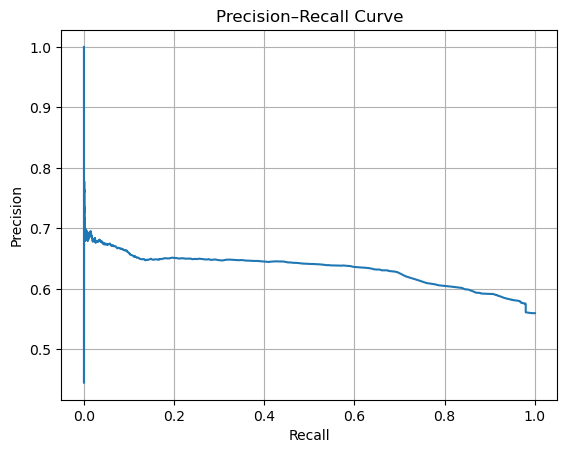

              precision    recall  f1-score   support

           0       0.59      0.26      0.36     36405
           1       0.60      0.86      0.70     46296

    accuracy                           0.60     82701
   macro avg       0.60      0.56      0.53     82701
weighted avg       0.60      0.60      0.55     82701



In [17]:

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

print("Average Precision (AP):", round(avg_precision, 3))

plt.figure()
plt.plot(recall, precision)
plt.title("Precision–Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

print(classification_report(y_test, (y_proba >= 0.5).astype(int)))


### 7) Try a Custom Threshold -- Update the code to fit your threshold and/or variable names from previous cells
Pick a threshold from your curve (e.g., a point balancing your business needs), then recompute metrics.


In [18]:
custom_threshold = 0.30
y_pred_custom = (y_proba >= custom_threshold).astype(int)

print("Custom threshold:", custom_threshold)
print(classification_report(y_test, y_pred_custom))

conf_matrix = confusion_matrix(y_test, y_pred_custom)
print("Confusion Matrix\n", conf_matrix)

Custom threshold: 0.3
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     36405
           1       0.56      1.00      0.72     46296

    accuracy                           0.56     82701
   macro avg       0.28      0.50      0.36     82701
weighted avg       0.31      0.56      0.40     82701

Confusion Matrix
 [[    0 36405]
 [    0 46296]]


/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## We Share — Reflection (Post 2 short paragraphs)

1) **Curve choice & results:** Which curve did you use (**ROC** or **PR**) and **why** (tie to class balance & business costs)? Report your curve summary (**AUC-ROC** or **Average Precision**) and your chosen extra metric (**precision/recall/F1**) — include threshold (0.5 or custom).  
- I chose the Precision–Recall curve because the data isn’t balanced—there are far fewer critical violations than regular inspection results. Since missing a true critical violation has a bigger real-world impact than flagging something by mistake, this curve gives a clearer picture of how well the model handles those rare cases. The model’s Average Precision score was 0.627, and at the standard 0.50 threshold, it reached 0.60 precision, 0.86 recall, and an F1 score around 0.70 for the critical class. In other words, the model is really good at catching most critical violations, but it does generate some false alerts along the way.

2) **Stakeholder one-liner:** In plain English: “Using **[features…]**, our model at threshold **T** yields **[metric values]**. This means **[business implication about false alarms vs misses]**. Next, we’d **[tune threshold, add features, address imbalance, etc.]**.”

> Tip: If the positive class is rare, PR is often more informative than ROC. If classes are balanced or you’re comparing ranking quality across models, AUC-ROC is fine — but still report a confusion matrix at your chosen threshold.

- Using features like inspection score and location, the model does a solid job of catching critical violations—about 86% of the time, it correctly flags them. The trade-off is that some of those alerts won’t actually be critical, but from a public health perspective, it’s better to check something extra than to miss a serious problem. In the future, we could adjust the threshold, add more useful features, or rebalance the data to help the model become more accurate without losing its ability to catch important cases.